# 01. A unit and its activation map

A conv layer with $K$ output channels has $K$ *units*. Unit $k$ applied to an image $x$ gives a 2D map $A_k(x)$ that says how strongly its pattern is present at each position. Network Dissection looks only at these maps and asks whether they line up with a concept.

Comparison in this notebook: a vertical edge unit vs a horizontal edge unit, then a hand made unit vs units learned by AlexNet.

Paper: Sec. 2.2, first step ("the activation map $A_k(x)$ of every internal convolutional unit $k$ is collected").

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models
from torchvision.transforms import functional as TF
from PIL import Image

plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 9})


def show(images, titles, cmap="gray", size=2.6):
    fig, axes = plt.subplots(1, len(images), figsize=(size * len(images), size))
    for ax, im, t in zip(np.atleast_1d(axes), images, titles):
        im = im.detach().cpu().numpy() if torch.is_tensor(im) else im
        ax.imshow(im, cmap=cmap)
        ax.set_title(t)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Two hand made units

A 1-channel image of a white square, and a conv layer with two units. Unit 0 holds a Sobel filter for vertical edges, unit 1 the same filter turned 90 degrees.

input shape  (1, 1, 32, 32) (batch, channels, height, width)
output shape (1, 2, 32, 32) (batch, units, height, width)


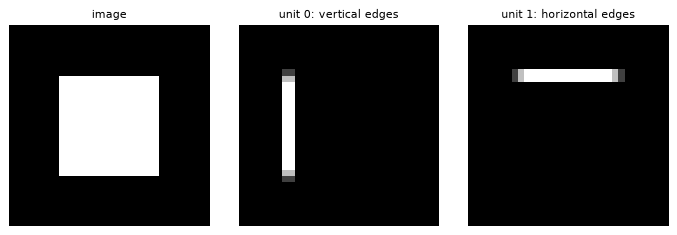

In [2]:
img = torch.zeros(1, 1, 32, 32)
img[..., 8:24, 8:24] = 1.0

sobel = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]])
layer = nn.Sequential(nn.Conv2d(1, 2, 3, padding=1, bias=False), nn.ReLU())
with torch.no_grad():
    layer[0].weight[0, 0] = sobel      # unit 0: dark to bright, left to right
    layer[0].weight[1, 0] = sobel.T    # unit 1: dark to bright, top to bottom
    a = layer(img)

print("input shape ", tuple(img.shape), "(batch, channels, height, width)")
print("output shape", tuple(a.shape), "(batch, units, height, width)")
show([img[0, 0], a[0, 0], a[0, 1]], ["image", "unit 0: vertical edges", "unit 1: horizontal edges"])

Each unit responds only to its own pattern, and only on one side of the square: the right and bottom edges go from bright to dark, which gives a negative response that the ReLU sets to 0.

## Reading a unit inside a network: forward hooks

The paper never modifies the network. It reads the maps during a normal forward pass. PyTorch offers *forward hooks*: a function attached to a module, called with its output each time the module runs.

In [3]:
stored = {}


def keep(name):
    def hook(module, inputs, output):
        stored[name] = output.detach().clone()
    return hook


handle = layer[1].register_forward_hook(keep("relu"))
with torch.no_grad():
    out = layer(img)
handle.remove()

print("hook saw:", tuple(stored["relu"].shape))
print("same as the layer output:", torch.equal(stored["relu"], out))

hook saw: (1, 2, 32, 32)
same as the layer output: True


Why `.clone()`: many networks use `ReLU(inplace=True)`, which overwrites a tensor in memory. Without a copy the stored map could change after the hook returns. A small demonstration:

In [4]:
torch.manual_seed(0)
x = torch.randn(1, 2, 4, 4)
net = nn.Sequential(nn.Conv2d(2, 2, 1), nn.ReLU(inplace=True))
saved = {}
h1 = net[0].register_forward_hook(lambda m, i, o: saved.__setitem__("no copy", o))
h2 = net[0].register_forward_hook(lambda m, i, o: saved.__setitem__("copy", o.clone()))
with torch.no_grad():
    net(x)
h1.remove()
h2.remove()
print("negative values kept without copy:", int((saved["no copy"] < 0).sum()))
print("negative values kept with copy:   ", int((saved["copy"] < 0).sum()))

negative values kept without copy: 0
negative values kept with copy:    18


The conv output had negative values, but the in place ReLU erased them from the uncopied tensor. The copy keeps the true conv output.

## Hand made vs learned units on a real image

Same idea on the meeting room image whose object map was decoded in notebook 00. Left: the two Sobel units applied to the gray image. Right: four units of the first layer of AlexNet trained on ImageNet, read with a hook. The ImageNet weights (233 MB) are downloaded by torchvision on the first run.

AlexNet conv1: (64, 56, 56) = 64 units on a 56 x 56 grid


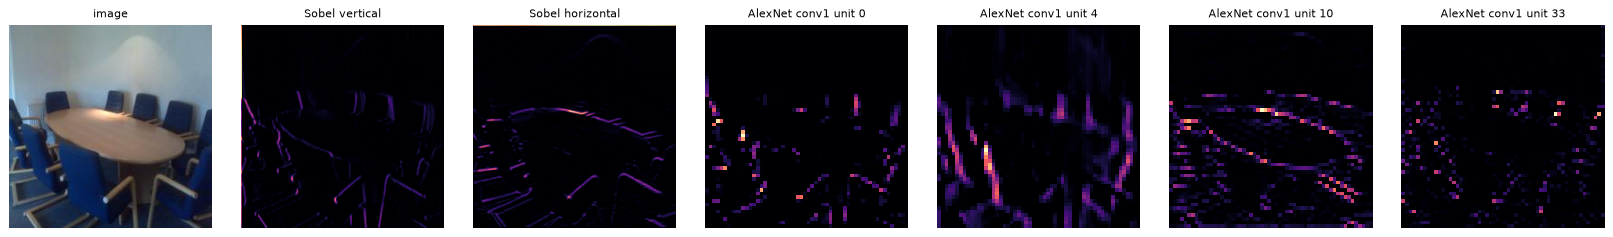

In [5]:
path = Path("data/broden1_227/images/ade20k/ADE_train_00006107.jpg")
rgb = TF.to_tensor(Image.open(path).convert("RGB"))
gray = rgb.mean(0, keepdim=True)[None]
with torch.no_grad():
    hand = layer(gray)[0]

alexnet = models.alexnet(weights="IMAGENET1K_V1").eval()
h = alexnet.features[1].register_forward_hook(keep("conv1"))
with torch.no_grad():
    alexnet(TF.normalize(rgb, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])[None])
h.remove()
learned = stored["conv1"][0]
print("AlexNet conv1:", tuple(learned.shape), "= 64 units on a 56 x 56 grid")

units = [0, 4, 10, 33]
show([rgb.permute(1, 2, 0), hand[0], hand[1]] + [learned[u] for u in units],
     ["image", "Sobel vertical", "Sobel horizontal"] + [f"AlexNet conv1 unit {u}" for u in units], cmap="magma")

AlexNet's first layer has a stride of 4, so a 227 × 227 image gives a 56 × 56 map. Each map value summarizes an 11 × 11 patch, which is why the AlexNet maps look coarser than the Sobel ones. Bringing such maps back to the image grid is the subject of notebook 04.

The filters of those AlexNet units, seen as small RGB images:

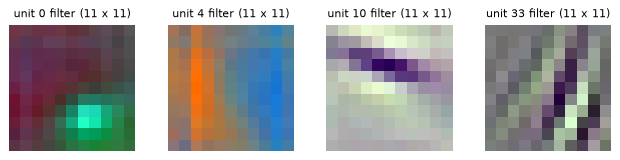

In [6]:
w = alexnet.features[0].weight.detach()[units]
w = (w - w.amin((1, 2, 3), keepdim=True)) / (w.amax((1, 2, 3), keepdim=True) - w.amin((1, 2, 3), keepdim=True))
show([wi.permute(1, 2, 0) for wi in w], [f"unit {u} filter (11 x 11)" for u in units], size=1.8)

Units 0 and 4 respond to color (a green blob, orange next to blue), units 10 and 33 to oriented edges and fine diagonal texture. Learned units also find edges, but in many orientations, colors and frequencies, without anyone choosing them.

## Takeaways

* One unit is one output channel. Its activation map shows where its pattern appears in the image.
* A forward hook reads that map during a normal forward pass, without changing the network. Copy the tensor, because in place operations can overwrite it.
* First layer units are simple detectors of edges and colors. The question of the paper is what units in deeper layers detect.

Next, notebook 02 turns concepts into pixel masks that these maps can be compared with.